# Practical: Logistic Regression – Customer Purchase Prediction

**Dataset:** Social Network Ads / Purchase Dataset  
**Objective:** To predict whether a customer will purchase a car based on Age and Estimated Salary using Logistic Regression.

## Problem Statement

A company is planning to launch a campaign for its new car brand and wants to analyze which customers are most likely to purchase the car.

Using data from a previous campaign, a Logistic Regression model is built to predict whether a customer will purchase the car or not.

## Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

## Load Dataset

In [4]:
PurchaseData = pd.read_csv("Purchase_Logistic - Purchase_Logistic.csv")
PurchaseData.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## Feature Selection

In [5]:
X = PurchaseData.iloc[:, [2, 3]].values   # Age, Estimated Salary
y = PurchaseData.iloc[:, 4].values        # Purchased

## Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

## Feature Scaling

In [7]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Train Logistic Regression Model

In [8]:
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

## Prediction

In [9]:
y_pred = classifier.predict(X_test)

## Model Evaluation

In [10]:
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)
print("Coefficients:", classifier.coef_)
print("Intercept:", classifier.intercept_)

Confusion Matrix:
 [[65  3]
 [ 8 24]]
Accuracy: 0.89
Coefficients: [[2.07665837 1.11008221]]
Intercept: [-0.95217247]


## Confusion Matrix Visualization

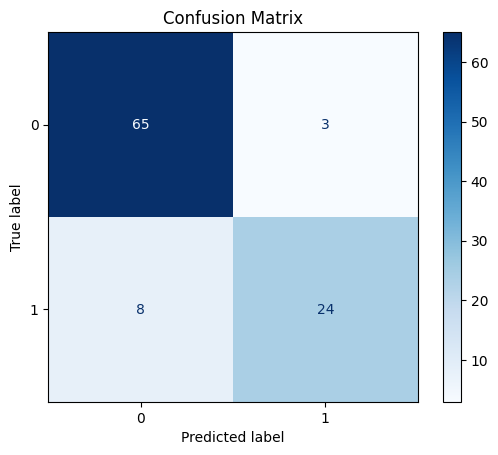

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Customer Purchase Distribution (Original Data)

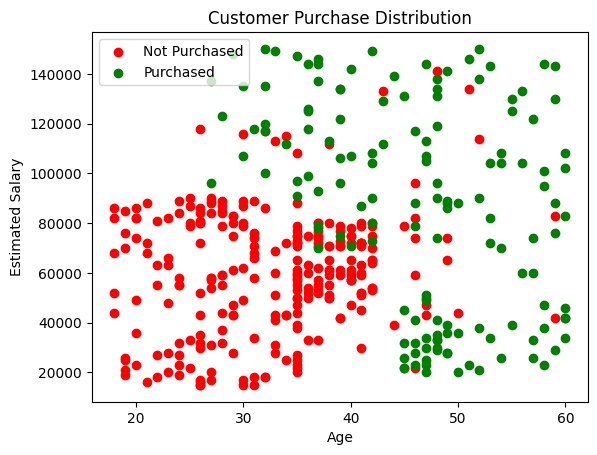

In [12]:
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
            color='red', label='Not Purchased')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='green', label='Purchased')

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Customer Purchase Distribution")
plt.legend()
plt.show()

## Decision Boundary (Training Set)

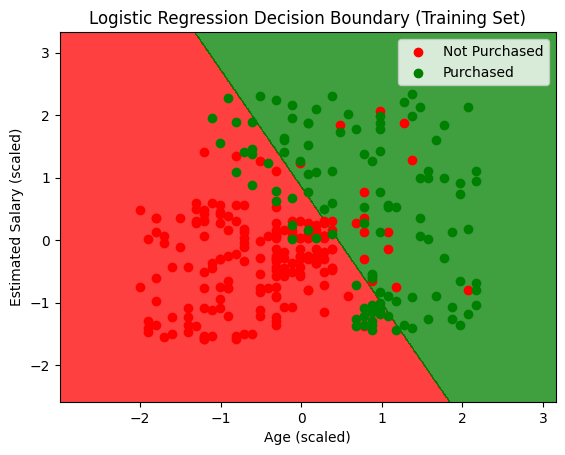

In [13]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
    np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T)
    .reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1],
            c='red', label='Not Purchased')
plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1],
            c='green', label='Purchased')

plt.title("Logistic Regression Decision Boundary (Training Set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.legend()
plt.show()

## Conclusion

Logistic Regression was successfully implemented to predict customer purchase behavior. Feature scaling improved model performance, and the confusion matrix along with accuracy score helped evaluate the classification results.